<a href="https://colab.research.google.com/github/jangirsachin9619-cpu/ml9-Support-Vector-Machine-SVM-/blob/main/8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path='/content/drive/MyDrive/deforestation_dataset.csv'
data=pd.read_csv(path)
data.head()

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,3,9.426264,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,4,2.602618,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,2,51.917315,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,4,23.716328,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,4,21.424037,159,41,18.085869


In [4]:
data.isnull().sum()

,0
Country,0
Year,0
Forest_Loss_Area_km2,0
Tree_Cover_Loss_percent,0
CO2_Emission_mt,0
Rainfall_mm,0
Population,0
GDP_Billion_USD,0
Agriculture_Land_Percent,0
Deforestation_Policy_Strictness,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          100 non-null    object 
 1   Year                             100 non-null    int64  
 2   Forest_Loss_Area_km2             100 non-null    int64  
 3   Tree_Cover_Loss_percent          100 non-null    float64
 4   CO2_Emission_mt                  100 non-null    int64  
 5   Rainfall_mm                      100 non-null    float64
 6   Population                       100 non-null    int64  
 7   GDP_Billion_USD                  100 non-null    float64
 8   Agriculture_Land_Percent         100 non-null    float64
 9   Deforestation_Policy_Strictness  100 non-null    int64  
 10  Corruption_Index                 100 non-null    float64
 11  International_Aid_Million_USD    100 non-null    int64  
 12  Illegal_Lumbering_Incid

In [7]:
data.fillna(data.mean(numeric_only=True),inplace=True)

In [8]:
data.fillna(data.ffill(axis=0),inplace=True)

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Corruption_Index']=le.fit_transform(data['Corruption_Index'])
data['Deforestation_Policy_Strictness']=le.fit_transform(data['Deforestation_Policy_Strictness'])
data

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,2,12,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,3,3,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,1,62,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,3,22,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,3,19,159,41,18.085869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Australia,2005,1809,1.544935,93,1893.986221,29915949,3312.288237,34.401813,1,21,291,95,24.221198
96,Australia,2001,2017,4.264310,440,1561.190914,81849918,4673.534282,49.675052,1,9,428,7,14.284021
97,Australia,1981,3960,2.316448,288,1442.880729,25174137,377.178732,22.751577,3,88,265,142,5.259525
98,Australia,1973,2466,6.562127,174,1671.741142,12523167,517.529578,17.310985,1,44,231,195,6.211250


In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()


numerical_cols = [
    'Forest_Loss_Area_km2',
    'Tree_Cover_Loss_percent',
    'CO2_Emission_mt',
    'Rainfall_mm',
    'Population',
    'GDP_Billion_USD',
    'Agriculture_Land_Percent',
    'Deforestation_Policy_Strictness',
    'Corruption_Index',
    'International_Aid_Million_USD',
    'Illegal_Lumbering_Incidents',
    'Protected_Areas_Percent'
]

for col in numerical_cols:
    data[col] = sc.fit_transform(data[[col]])

data

,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,-1.435847,1.353354,0.412992,-0.611514,1.427134,0.020789,1.656028,0.367855,-1.299103,-0.070580,1.360924,-1.353582
1,Brazil,1927,0.702287,-0.381103,0.694820,-0.925249,1.321640,0.081370,-1.378318,1.243702,-1.610888,1.178629,-0.389567,0.337820
2,Russia,1961,1.608830,-0.364583,0.367290,-0.422713,-0.185985,0.252244,0.684164,-0.507991,0.433034,-0.431463,-0.868475,0.688477
3,Australia,1967,0.979005,-1.635268,0.268270,-0.774312,0.882666,0.002291,-1.606142,1.243702,-0.952676,-0.403703,-1.644635,0.682478
4,Australia,1987,0.218225,0.992090,1.525069,-0.408543,-1.084459,-1.346385,-1.353690,1.243702,-1.056604,-0.618845,-1.000587,0.083757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Australia,2005,-0.462267,-1.631465,-1.194188,-0.164546,-0.597853,0.555927,-0.020038,-0.507991,-0.987318,0.297243,-0.108828,0.879631
96,Australia,2001,-0.300134,-0.532323,1.448900,-0.740487,1.252225,1.513810,1.007432,-0.507991,-1.403031,1.248030,-1.562065,-0.409418
97,Australia,1981,1.214410,-1.319628,0.291121,-0.945236,-0.766774,-1.509454,-0.803779,1.243702,1.333746,0.116801,0.667333,-1.580073
98,Australia,1973,0.049856,0.396430,-0.577214,-0.549167,-1.217448,-1.410692,-1.169781,-0.507991,-0.190535,-0.119161,1.542579,-1.456616


In [17]:
y = data['Forest_Loss_Area_km2']
X = data.drop(['Country', 'Year', 'Forest_Loss_Area_km2'], axis=1)
print("Features (X) and Target (y) variables created.")

Features (X) and Target (y) variables created.


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data successfully split into training and testing sets.")

Data successfully split into training and testing sets.


In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

feature_importances = model.feature_importances_
print("RandomForestRegressor model trained and feature importances extracted.")

RandomForestRegressor model trained and feature importances extracted.


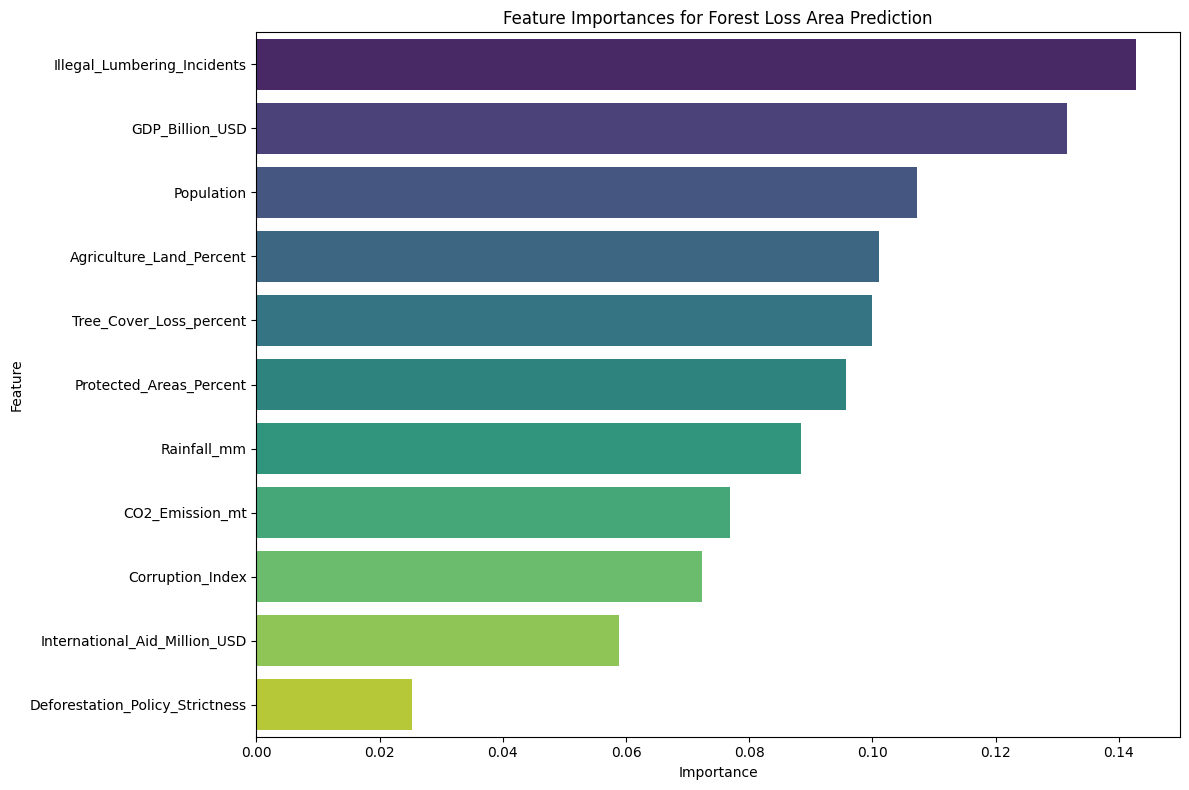

Feature importances visualized successfully.


In [21]:
feature_importances_df = pd.Series(feature_importances, index=X.columns)

# Sort the features by importance
sorted_importances = feature_importances_df.sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis', hue=sorted_importances.index, legend=False)
plt.title('Feature Importances for Forest Loss Area Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importances visualized successfully.")

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

y_train_cat = pd.qcut(y_train, q=4, labels=False, duplicates='drop') # Convert continuous target to 4 categories
y_test_cat = pd.qcut(y_test, q=4, labels=False, duplicates='drop') # Convert continuous target to 4 categories


print("Training SVM model with linear kernel...")
model=SVC(kernel='linear', random_state=42)
model.fit(X_train,y_train_cat)

print("\n--- Performance on Training Data ---")
y_train_pred = model.predict(X_train)
print("Confusion Matrix (Train):\n", confusion_matrix(y_train_cat, y_train_pred))
print("Classification Report (Train):\n", classification_report(y_train_cat, y_train_pred))

print("\n--- Performance on Test Data ---")
y_pred=model.predict(X_test)
print("Confusion Matrix (Test):\n", confusion_matrix(y_test_cat,y_pred))
print("Classification Report (Test):\n", classification_report(y_test_cat,y_pred))
con=confusion_matrix(y_test_cat,y_pred)
print("Test Confusion Matrix Variable 'con':\n", con)

Training SVM model with linear kernel...

--- Performance on Training Data ---
Confusion Matrix (Train):
 [[ 9  5  4  2]
 [ 5 13  2  0]
 [ 4  2 12  2]
 [ 1  4  6  9]]
Classification Report (Train):
               precision    recall  f1-score   support

           0       0.47      0.45      0.46        20
           1       0.54      0.65      0.59        20
           2       0.50      0.60      0.55        20
           3       0.69      0.45      0.55        20

    accuracy                           0.54        80
   macro avg       0.55      0.54      0.54        80
weighted avg       0.55      0.54      0.54        80


--- Performance on Test Data ---
Confusion Matrix (Test):
 [[2 0 1 2]
 [1 1 2 1]
 [1 1 2 1]
 [1 0 1 3]]
Classification Report (Test):
               precision    recall  f1-score   support

           0       0.40      0.40      0.40         5
           1       0.50      0.20      0.29         5
           2       0.33      0.40      0.36         5
           3 

In [34]:
from sklearn.svm import SVR

print("Training SVR model with linear kernel...")
svr_model = SVR(kernel='linear')
svr_model.fit(X_train, y_train)

print("SVR model trained successfully.")

Training SVR model with linear kernel...
SVR model trained successfully.


In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

# Make predictions on the training set
y_train_pred_svr = svr_model.predict(X_train)

# Make predictions on the test set
y_test_pred_svr = svr_model.predict(X_test)

print("--- SVR Model Performance ---")

# Evaluate training performance
mae_train_svr = mean_absolute_error(y_train, y_train_pred_svr)
r2_train_svr = r2_score(y_train, y_train_pred_svr)
print(f"\nTraining Mean Absolute Error (MAE): {mae_train_svr:.4f}")
print(f"Training R-squared (R2): {r2_train_svr:.4f}")

# Evaluate test performance
mae_test_svr = mean_absolute_error(y_test, y_test_pred_svr)
r2_test_svr = r2_score(y_test, y_test_pred_svr)
print(f"\nTest Mean Absolute Error (MAE): {mae_test_svr:.4f}")
print(f"Test R-squared (R2): {r2_test_svr:.4f}")

--- SVR Model Performance ---

Training Mean Absolute Error (MAE): 0.7445
Training R-squared (R2): -0.0217

Test Mean Absolute Error (MAE): 1.1016
Test R-squared (R2): -1.6202


In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate MSE for training set
mse_train_svr = mean_squared_error(y_train, y_train_pred_svr)
rmse_train_svr = np.sqrt(mse_train_svr)

# Calculate MSE for test set
mse_test_svr = mean_squared_error(y_test, y_test_pred_svr)
rmse_test_svr = np.sqrt(mse_test_svr)

print(f"Training Mean Squared Error (MSE): {mse_train_svr:.4f}")
print(f"Training Root Mean Squared Error (RMSE): {rmse_train_svr:.4f}")
print(f"\nTest Mean Squared Error (MSE): {mse_test_svr:.4f}")
print(f"Test Root Mean Squared Error (RMSE): {rmse_test_svr:.4f}")

Training Mean Squared Error (MSE): 1.0472
Training Root Mean Squared Error (RMSE): 1.0233

Test Mean Squared Error (MSE): 1.7022
Test Root Mean Squared Error (RMSE): 1.3047


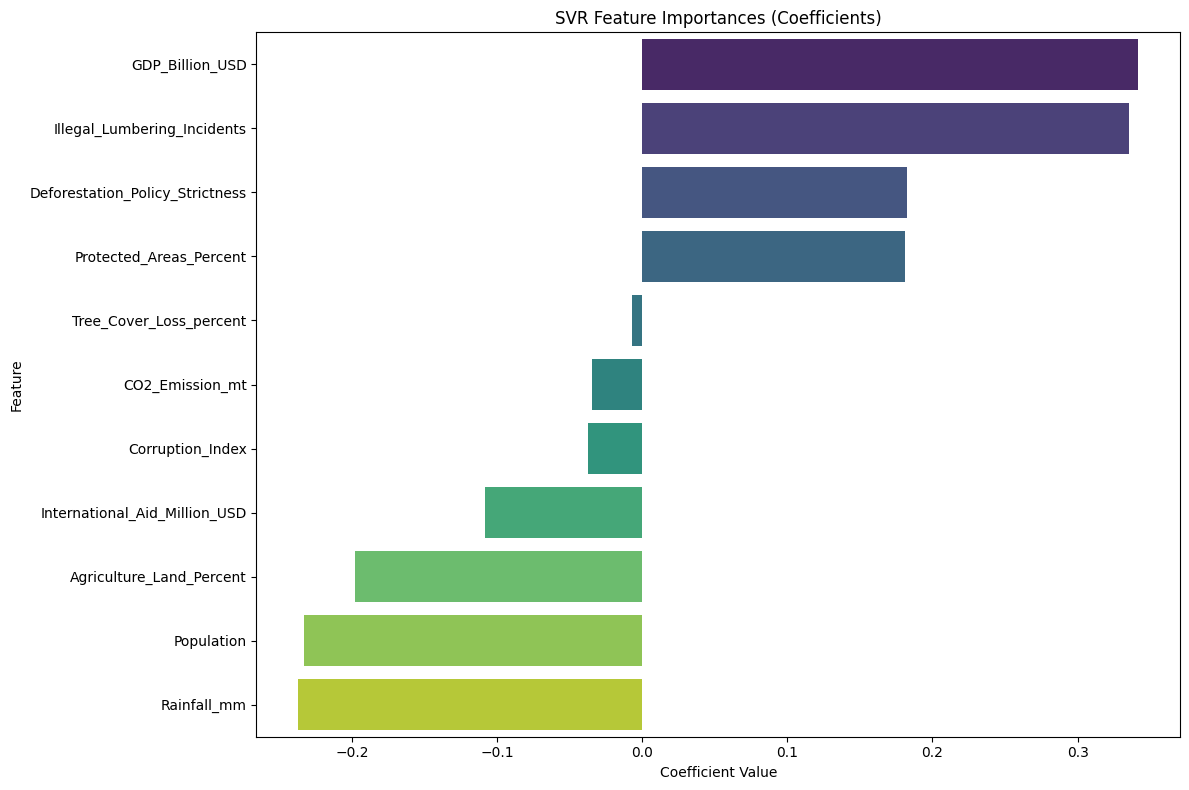

SVR feature importances (coefficients) visualized successfully.


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Access the coefficients from the SVR model
svr_coefficients = svr_model.coef_[0]

# Create a Pandas Series with feature names as index
feature_importance_svr = pd.Series(svr_coefficients, index=X.columns)

# Sort the features by importance (absolute value for clearer comparison, but original values are better for impact direction)
sorted_importance_svr = feature_importance_svr.sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importance_svr.values, y=sorted_importance_svr.index, palette='viridis', hue=sorted_importance_svr.index, legend=False)
plt.title('SVR Feature Importances (Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("SVR feature importances (coefficients) visualized successfully.")

In [44]:
from scipy.stats import loguniform

param_distributions = {
    'C': loguniform(0.1, 1000),
    'gamma': loguniform(0.001, 1),
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

print("Parameter distributions defined successfully.")

Parameter distributions defined successfully.


In [46]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR

# Instantiate SVR model without random_state
svr = SVR()

# Initialize RandomizedSearchCV
random_search_svr = RandomizedSearchCV(
    estimator=svr,
    param_distributions=param_distributions,
    n_iter=50, # Number of parameter settings that are sampled
    cv=5,      # 5-fold cross-validation
    verbose=2, # Verbose output
    random_state=42, # random_state for reproducibility of the search
    n_jobs=-1  # Use all available cores
)

print("Performing RandomizedSearchCV...")
# Fit RandomizedSearchCV to the training data
random_search_svr.fit(X_train, y_train)

print("RandomizedSearchCV completed.")
print(f"Best parameters found: {random_search_svr.best_params_}")
print(f"Best R-squared score: {random_search_svr.best_score_:.4f}")

Performing RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV completed.
Best parameters found: {'C': np.float64(3.14891164795686), 'gamma': np.float64(0.711447600934342), 'kernel': 'rbf'}
Best R-squared score: -0.0515


In [48]:
best_params = random_search_svr.best_params_

print(f"Best parameters for SVR: {best_params}")

# Instantiate a new SVR model with the best parameters
best_svr_model = SVR(
    C=best_params['C'],
    gamma=best_params['gamma'],
    kernel=best_params['kernel']
)

# Train the new SVR model on the full training dataset
best_svr_model.fit(X_train, y_train)

print("Final SVR model trained successfully with best parameters.")

Best parameters for SVR: {'C': np.float64(3.14891164795686), 'gamma': np.float64(0.711447600934342), 'kernel': 'rbf'}
Final SVR model trained successfully with best parameters.


In [49]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Make predictions on the training set
y_train_pred_best_svr = best_svr_model.predict(X_train)

# Make predictions on the test set
y_test_pred_best_svr = best_svr_model.predict(X_test)

print("--- Best SVR Model Performance (After RandomizedSearchCV) ---")

# Evaluate training performance
mae_train_best_svr = mean_absolute_error(y_train, y_train_pred_best_svr)
r2_train_best_svr = r2_score(y_train, y_train_pred_best_svr)
mse_train_best_svr = mean_squared_error(y_train, y_train_pred_best_svr)
rmse_train_best_svr = np.sqrt(mse_train_best_svr)

print(f"\nTraining Mean Absolute Error (MAE): {mae_train_best_svr:.4f}")
print(f"Training R-squared (R2): {r2_train_best_svr:.4f}")
print(f"Training Mean Squared Error (MSE): {mse_train_best_svr:.4f}")
print(f"Training Root Mean Squared Error (RMSE): {rmse_train_best_svr:.4f}")

# Evaluate test performance
mae_test_best_svr = mean_absolute_error(y_test, y_test_pred_best_svr)
r2_test_best_svr = r2_score(y_test, y_test_pred_best_svr)
mse_test_best_svr = mean_squared_error(y_test, y_test_pred_best_svr)
rmse_test_best_svr = np.sqrt(mse_test_best_svr)

print(f"\nTest Mean Absolute Error (MAE): {mae_test_best_svr:.4f}")
print(f"Test R-squared (R2): {r2_test_best_svr:.4f}")
print(f"Test Mean Squared Error (MSE): {mse_test_best_svr:.4f}")
print(f"Test Root Mean Squared Error (RMSE): {rmse_test_best_svr:.4f}")

--- Best SVR Model Performance (After RandomizedSearchCV) ---

Training Mean Absolute Error (MAE): 0.0986
Training R-squared (R2): 0.9904
Training Mean Squared Error (MSE): 0.0098
Training Root Mean Squared Error (RMSE): 0.0990

Test Mean Absolute Error (MAE): 0.8188
Test R-squared (R2): -0.4796
Test Mean Squared Error (MSE): 0.9612
Test Root Mean Squared Error (RMSE): 0.9804
